# 3-Way Pipeline Comparison

Three self-contained Python scripts under `comparisons/`, each runs a full 8-query RAG pipeline end-to-end and returns the same result schema:

| # | Script | What it represents |
|---|--------|--------------------|
| 1 | `comparisons/run_bruteforce.py` | **Pure BruteForce, zero optimizations** — serial, non-streaming, no norm cache |
| 2 | `comparisons/run_intermediate.py` | **IVF with default settings** — structural optimization only, no Numba / streaming / pipelining |
| 3 | `comparisons/run_optimized.py` | **Fully optimized** — Steps 1-6 all applied (Numba K-Means++, norm cache, np gather, streaming, pipelined) |

Each script makes 8 real Kong gpt-4o calls (~$0.03 each, $0.10 total).

**Pipeline stages common to all 3:** LocalEmbedder (CPU) → index search → gpt-4o generation.

**What changes between the 3:** the index, the similarity path, the generator mode, and whether stages overlap.

## 1. Setup and run all 3 configurations

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / 'comparisons'))

# Each script's top-level setup_cpu_only() runs on import -- force CPU, hide CUDA
from comparisons import run_bruteforce, run_intermediate, run_optimized
from comparisons.common import save_result, PROJECT_ROOT

import numpy as np
import matplotlib.pyplot as plt

[common] Numba cache -> C:\Users\郝治寰\AppData\Local\Temp\numba_cache
[common] Numba cache -> C:\Users\郝治寰\AppData\Local\Temp\numba_cache
[common] Numba cache -> C:\Users\郝治寰\AppData\Local\Temp\numba_cache


In [2]:
# Change these to benchmark differently. n_queries=8 keeps API cost ~$0.10.
DATASET    = 'medium'
N_QUERIES  = 8
K          = 5           # top-K chunks retrieved per query
MAX_TOKENS = 256

configs = {}

configs['bruteforce']   = run_bruteforce.run(
    dataset=DATASET, n_queries=N_QUERIES, k=K, max_tokens=MAX_TOKENS,
)
save_result(configs['bruteforce'],   '01_bruteforce')

configs['intermediate'] = run_intermediate.run(
    dataset=DATASET, n_queries=N_QUERIES, k=K, max_tokens=MAX_TOKENS,
    n_clusters=32, n_probes=4,
)
save_result(configs['intermediate'], '02_intermediate')

configs['optimized']    = run_optimized.run(
    dataset=DATASET, n_queries=N_QUERIES, k=K, max_tokens=MAX_TOKENS,
    n_clusters=64, n_probes=8,
    n_embed_workers=4, n_gen_workers=8,
)
save_result(configs['optimized'],    '03_optimized')


[Config 1: BruteForce, no optim] dataset=medium, n_queries=8
Building BruteForceIndex...
BruteForceIndex built: 100000 vectors in 0.092s
Warming up embedder (loading MiniLM model)...


d:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading embedding model: all-MiniLM-L6-v2 (device=cpu)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8401.33it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model loaded in 16823 ms

Running 8 queries end-to-end (serial, non-streaming)...
  [1/8] 'what is rba...' embed=    7 search= 63.1 gen= 3135 total= 3206  recall=1.000
  [2/8] 'was ronald reagan a democrat...' embed=    8 search= 56.9 gen= 1152 total= 1217  recall=1.000
  [3/8] 'how long do you need for sydney and surr...' embed=    8 search= 63.4 gen= 1662 total= 1733  recall=1.000
  [4/8] 'price to install tile in shower...' embed=    8 search= 63.3 gen= 1519 total= 1590  recall=1.000
  [5/8] 'why conversion observed in body...' embed=    8 search= 66.6 gen= 1789 total= 1863  recall=1.000
  [6/8] 'where are the lungs located in the back...' embed=    8 search= 63.0 gen= 1829 total= 1900  recall=0.000
  [7/8] 'cost to get a patent...' embed=    8 search= 61.7 gen= 1552 total= 1622  recall=1.000
  [8/8] 'best tragedies of ancient greece...' embed=   10 search= 65.4 gen= 1394 total= 1469  recall=0.000

--- Config 1: BruteForce (no optim) ---
  Build:              129.9 ms
  Mean embed

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7508.18it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model loaded in 1318 ms

Running 8 queries end-to-end (serial, non-streaming, norm cache OFF, np gather OFF)...
  [1/8] 'what is rba...' embed=    8 search= 13.6 gen= 1913 total= 1934  recall=1.000
  [2/8] 'was ronald reagan a democrat...' embed=    7 search= 13.4 gen= 1542 total= 1563  recall=1.000
  [3/8] 'how long do you need for sydney and surr...' embed=    8 search= 17.9 gen= 1986 total= 2011  recall=0.000
  [4/8] 'price to install tile in shower...' embed=    8 search= 22.6 gen= 2290 total= 2321  recall=1.000
  [5/8] 'why conversion observed in body...' embed=    7 search= 13.4 gen= 1753 total= 1773  recall=0.000
  [6/8] 'where are the lungs located in the back...' embed=    8 search= 15.4 gen= 1327 total= 1351  recall=0.000
  [7/8] 'cost to get a patent...' embed=    7 search= 23.6 gen= 1531 total= 1562  recall=1.000
  [8/8] 'best tragedies of ancient greece...' embed=    8 search= 13.8 gen= 1436 total= 1458  recall=0.000

--- Config 2: IVF(32, np=4) default ---
  Build:     

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6657.83it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Model loaded in 1250 ms

Running 8 queries PIPELINED (streaming, norm cache ON, np gather ON)...
  [1/8] 'what is rba...' embed=   36 search=11.96 TTFT= 2751 gen_total= 2887  recall=1.000
  [2/8] 'was ronald reagan a democrat...' embed=   36 search=12.78 TTFT=  804 gen_total=  837  recall=1.000
  [3/8] 'how long do you need for sydney and surr...' embed=   36 search=14.42 TTFT=  937 gen_total=  976  recall=1.000
  [4/8] 'price to install tile in shower...' embed=   35 search=17.42 TTFT= 1463 gen_total= 1516  recall=1.000
  [5/8] 'why conversion observed in body...' embed=   43 search=12.91 TTFT= 1142 gen_total= 1172  recall=0.000
  [6/8] 'where are the lungs located in the back...' embed=   40 search=15.60 TTFT= 2988 gen_total= 3039  recall=0.000
  [7/8] 'cost to get a patent...' embed=   37 search=18.64 TTFT= 1290 gen_total= 1362  recall=1.000
  [8/8] 'best tragedies of ancient greece...' embed=   36 search=12.05 TTFT=  956 gen_total=  999  recall=0.000

--- Config 3: Fully optimize

WindowsPath('D:/Zhihuan Hao Important Documents/NYU Grad Study Materials/Spring 2026/Advanced Python/Retrieval-Augmented-Generation-Optimization-Test/results/comparisons/03_optimized.json')

## 2. Visualization — 4-panel comparison

- **Panel A (top-left):** stacked per-query breakdown (embed / search / gen)
- **Panel B (top-right):** batch total time (where pipelining matters)
- **Panel C (bottom-left):** Recall@10 — quality comparison
- **Panel D (bottom-right):** build time — one-time offline cost

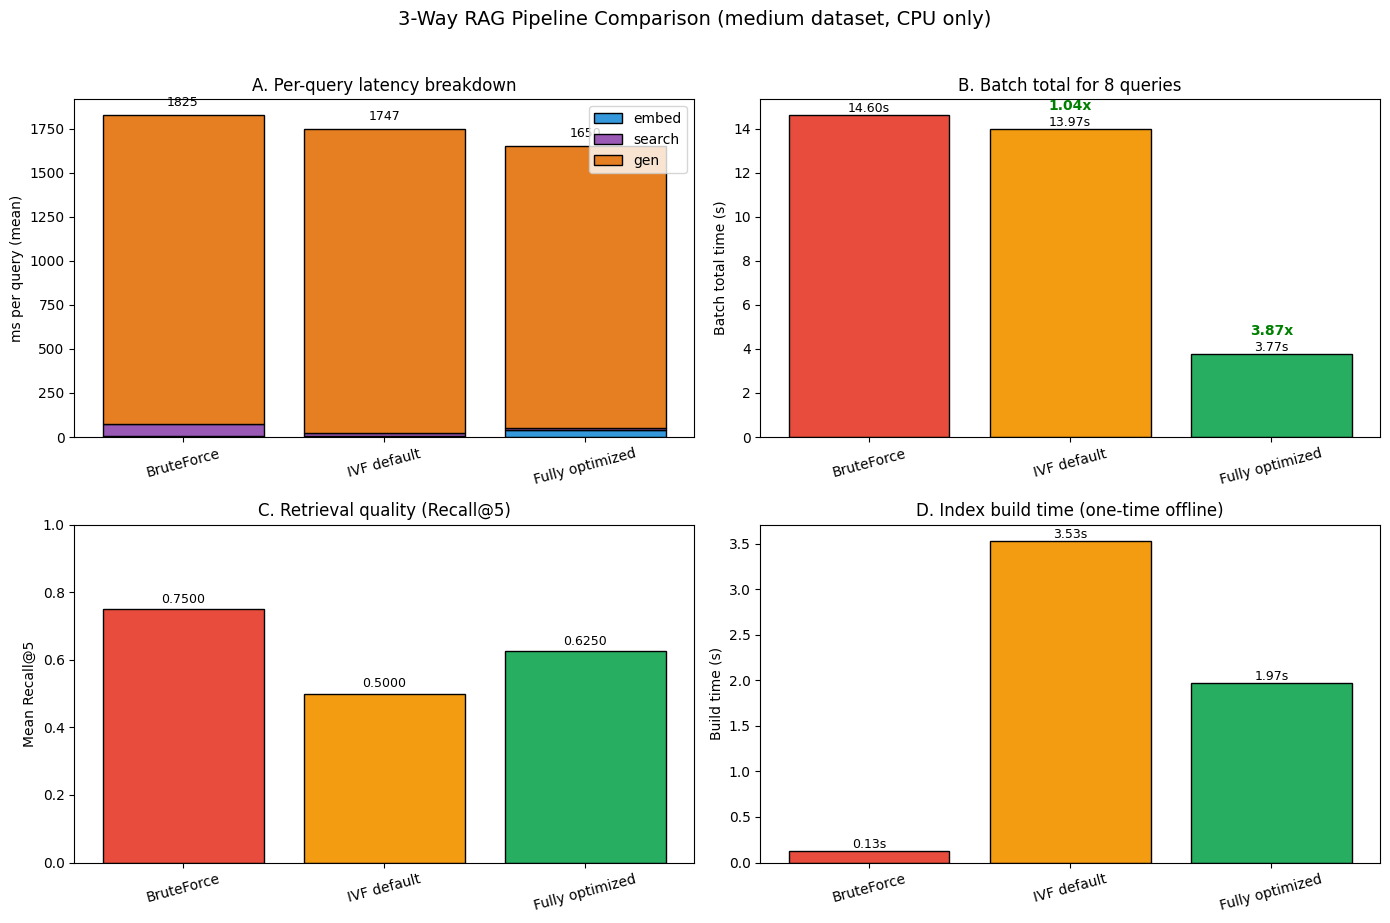

In [3]:
def plot_comparison(configs):
    names  = [configs['bruteforce']['name'],
              configs['intermediate']['name'],
              configs['optimized']['name']]
    short  = ['BruteForce', 'IVF default', 'Fully optimized']
    colors = ['#e74c3c', '#f39c12', '#27ae60']

    # Read k from the config dict so the label matches what was actually retrieved
    k_val  = configs['bruteforce']['config'].get('n_retrieved', '?')

    per_q = [c['per_query_mean']              for c in configs.values()]
    embed = [m['embed_ms']                    for m in per_q]
    search= [m['search_ms']                   for m in per_q]
    gen   = [m['gen_ms']                      for m in per_q]
    total = [m['total_ms']                    for m in per_q]
    recall= [m['recall@k']                    for m in per_q]
    batch = [c['batch_total_ms']/1000         for c in configs.values()]   # seconds
    build = [c['build_time_ms']/1000          for c in configs.values()]   # seconds

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # Panel A: stacked per-query breakdown
    ax = axes[0, 0]
    x = np.arange(len(short))
    ax.bar(x, embed,  label='embed',  color='#3498db', edgecolor='black')
    ax.bar(x, search, bottom=embed, label='search', color='#9b59b6', edgecolor='black')
    ax.bar(x, gen,    bottom=[e+s for e, s in zip(embed, search)],
           label='gen',    color='#e67e22', edgecolor='black')
    ax.set_ylabel('ms per query (mean)')
    ax.set_title('A. Per-query latency breakdown')
    ax.set_xticks(x); ax.set_xticklabels(short, rotation=15)
    ax.legend(loc='upper right')
    for i, t in enumerate(total):
        ax.text(i, t * 1.02, f'{t:.0f}', ha='center', va='bottom', fontsize=9)

    # Panel B: batch total
    ax = axes[0, 1]
    bars = ax.bar(short, batch, color=colors, edgecolor='black')
    ax.set_ylabel('Batch total time (s)')
    ax.set_title(f'B. Batch total for {configs["bruteforce"]["n_queries"]} queries')
    ax.tick_params(axis='x', rotation=15)
    for bar, t in zip(bars, batch):
        ax.text(bar.get_x() + bar.get_width()/2, t, f'{t:.2f}s',
                ha='center', va='bottom', fontsize=9)
    # Add speedup annotation vs config 1
    base = batch[0]
    for i, t in enumerate(batch[1:], start=1):
        ax.text(i, t + base*0.05, f'{base/t:.2f}x', ha='center', va='bottom',
                fontsize=10, color='green', weight='bold')

    # Panel C: Recall @ k
    ax = axes[1, 0]
    bars = ax.bar(short, recall, color=colors, edgecolor='black')
    ax.set_ylabel(f'Mean Recall@{k_val}')
    ax.set_title(f'C. Retrieval quality (Recall@{k_val})')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=15)
    for bar, r in zip(bars, recall):
        ax.text(bar.get_x() + bar.get_width()/2, r + 0.01, f'{r:.4f}',
                ha='center', va='bottom', fontsize=9)

    # Panel D: build time
    ax = axes[1, 1]
    bars = ax.bar(short, build, color=colors, edgecolor='black')
    ax.set_ylabel('Build time (s)')
    ax.set_title('D. Index build time (one-time offline)')
    ax.tick_params(axis='x', rotation=15)
    for bar, t in zip(bars, build):
        ax.text(bar.get_x() + bar.get_width()/2, t, f'{t:.2f}s',
                ha='center', va='bottom', fontsize=9)

    fig.suptitle('3-Way RAG Pipeline Comparison (medium dataset, CPU only)',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_comparison(configs)

## 3. Numeric summary table

In [4]:
def print_comparison_table(configs):
    k_val = configs['bruteforce']['config'].get('n_retrieved', '?')

    header = ('Metric', 'BruteForce', 'IVF default', 'Fully optimized', 'Opt speedup vs BF')
    print(f'{header[0]:<22s} {header[1]:>12s} {header[2]:>12s} {header[3]:>18s} {header[4]:>20s}')
    print('-' * 90)

    def eval_dotted(d, dotted):
        for part in dotted.split('.'):
            d = d[part]
        return d

    def row(label, key, fmt='{:>12.2f}', speedup_cmp='smaller'):
        bf_v  = eval_dotted(configs['bruteforce'],   key)
        im_v  = eval_dotted(configs['intermediate'], key)
        op_v  = eval_dotted(configs['optimized'],    key)
        speed = (bf_v / op_v) if speedup_cmp == 'smaller' else (op_v / bf_v)
        print(f'{label:<22s} {fmt.format(bf_v):>12s} {fmt.format(im_v):>12s} '
              f'{fmt.format(op_v):>18s} {speed:>18.2f}x')

    row('Build time (ms)',          'build_time_ms',                 '{:>12.1f}')
    row('Embed ms/query',            'per_query_mean.embed_ms',      '{:>12.1f}')
    row('Search ms/query',           'per_query_mean.search_ms',     '{:>12.3f}')
    row('Gen ms/query',              'per_query_mean.gen_ms',        '{:>12.0f}')
    row('Total ms/query',            'per_query_mean.total_ms',      '{:>12.0f}')
    row('Batch total ms',            'batch_total_ms',               '{:>12.0f}')
    row(f'Recall@{k_val}',           'per_query_mean.recall@k',      '{:>12.4f}',
        speedup_cmp='bigger')


print_comparison_table(configs)

Metric                   BruteForce  IVF default    Fully optimized    Opt speedup vs BF
------------------------------------------------------------------------------------------
Build time (ms)               129.9       3529.7             1971.5               0.07x
Embed ms/query                  8.1          7.6               37.2               0.22x
Search ms/query              62.914       16.713             14.471               4.35x
Gen ms/query                   1754         1722               1598               1.10x
Total ms/query                 1825         1747               1650               1.11x
Batch total ms                14601        13974               3770               3.87x
Recall@5                     0.7500       0.5000             0.6250               0.83x


## 4. Save combined results for later reference

In [5]:
import json
from comparisons.common import _json_safe

out_path = PROJECT_ROOT / 'results' / 'comparisons' / 'three_way_comparison.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(_json_safe({
        'dataset':    DATASET,
        'n_queries':  N_QUERIES,
        'k':          K,
        'max_tokens': MAX_TOKENS,
        'configs':    configs,
    }), f, indent=2)
print(f'Saved: {out_path}')

Saved: D:\Zhihuan Hao Important Documents\NYU Grad Study Materials\Spring 2026\Advanced Python\Retrieval-Augmented-Generation-Optimization-Test\results\comparisons\three_way_comparison.json
